In [3]:
import os
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

semilla = 42
random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

path = os.path.join(os.getcwd(), "ibm.us.csv")
dataset = pd.read_csv(path)
dataset["promedioDia"] = (dataset["High"]+dataset["Low"])/2
dataset["Date"] = pd.to_datetime(dataset["Date"])

#70% train, 15% validation, 15% test
n = len(dataset)

train = dataset[:int(n*0.7)][["promedioDia"]].to_numpy()
validation = dataset[int(n*0.7):int(n*0.85)][["promedioDia"]].to_numpy()
test = dataset[int(n*0.85):][["promedioDia"]].to_numpy()

print("Conjunto de entrenamiento: ",train[:5])
print("Conjunto de validación: ",validation[:5])
print("Conjunto de prueba: ",test[:5])

#Hallar la media y desviación del entrenamiento
media = train.mean()
desvest  = train.std()

#Normalizar los 3 subconjuntos respecto a los valores calculados
train = (train - media) / desvest
validation   = (validation   - media) / desvest
test  = (test  - media) / desvest

train2D = train.reshape(-1, 1)
validation2D = validation.reshape(-1, 1)
test2D = test.reshape(-1, 1)

Conjunto de entrenamiento:  [[6.3754 ]
 [6.36705]
 [6.3629 ]
 [6.25845]
 [6.1207 ]]
Conjunto de validación:  [[96.151 ]
 [96.9425]
 [94.351 ]
 [94.384 ]
 [96.2135]]
Conjunto de prueba:  [[87.6125]
 [88.094 ]
 [85.8565]
 [84.6285]
 [84.332 ]]


In [4]:
def graficaeMAE(history, titulo, ax=None):
  if ax is None:
    ax = plt.gca()

  loss = history.history["mae"]
  val_loss = history.history["val_mae"]
  epochs = range(1, len(loss) + 1)

  ax.plot(epochs, loss, "o-", label="MAE Entrenamiento")
  ax.plot(epochs, val_loss, "-", label="MAE Validación")
  ax.set_title(titulo)
  ax.set_xlabel("Época")
  ax.set_ylabel("MAE")
  ax.legend()

def graficarPrediccion(prediccion, y, titulo, ax=None):
  rango=(20, 70)
  
  if ax is None:
    ax = plt.gca()
        
  start, end = rango
  ax.plot(y[start:end], label="Valor Real")
  ax.plot(prediccion[start:end], label="Predicción")
  ax.set_title(titulo)
  ax.set_xlabel("Índice")
  ax.set_ylabel("Valor")
  ax.legend()

In [5]:
#Ventanas de 3 días con muestras diarias
sampling_rate = 1
sequence_length = 3
delay = 1 
batch_size = 32
cantNeuronas = 15
epocas = 50

In [10]:
#Definir los nuevo dataset
datasetTrainApilado = keras.utils.timeseries_dataset_from_array(
  data = train2D[:-delay],
  targets=train2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0
)

datasetValidationApilado = keras.utils.timeseries_dataset_from_array(
  data = validation2D[:-delay],
  targets=validation2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
)

datasetTestApilado = keras.utils.timeseries_dataset_from_array(
  data = test2D[:-delay],
  targets=test2D[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=False,
  batch_size=batch_size,
  start_index=0
)

In [12]:
#Entrenar Modelo

def entrenarApilado(modelo, cantCapas):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  
  #Entrenar el modelo
  cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
  modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])    

  history = modelo.fit(
    datasetTrainApilado,
    epochs=epocas,
    validation_data=datasetValidationApilado,
    callbacks=cb,
    verbose=0   
  )

  #Evaluar el modelo
  mae = modelo.evaluate(datasetTestApilado, verbose=0)[1]
  y = np.concatenate([y for x, y in datasetTestApilado], axis=0)
  pred = modelo.predict(datasetTestApilado)  
  graficaeMAE(history, f"MAE de Entrenamiento y Validación - LSTM - {cantCapas} Capas Apiladas", axes[0])
  graficarPrediccion(pred, y, f"Predicción vs Valor Real - LSTM - {cantCapas} Capas Apiladas", axes[1])

  print(f"MAE de prueba - {cantCapas} Capas Apiladas): {mae:.4f}")

  plt.tight_layout()
  plt.show()

Una capa

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MAE de prueba - 1 Capas Apiladas): 0.9107


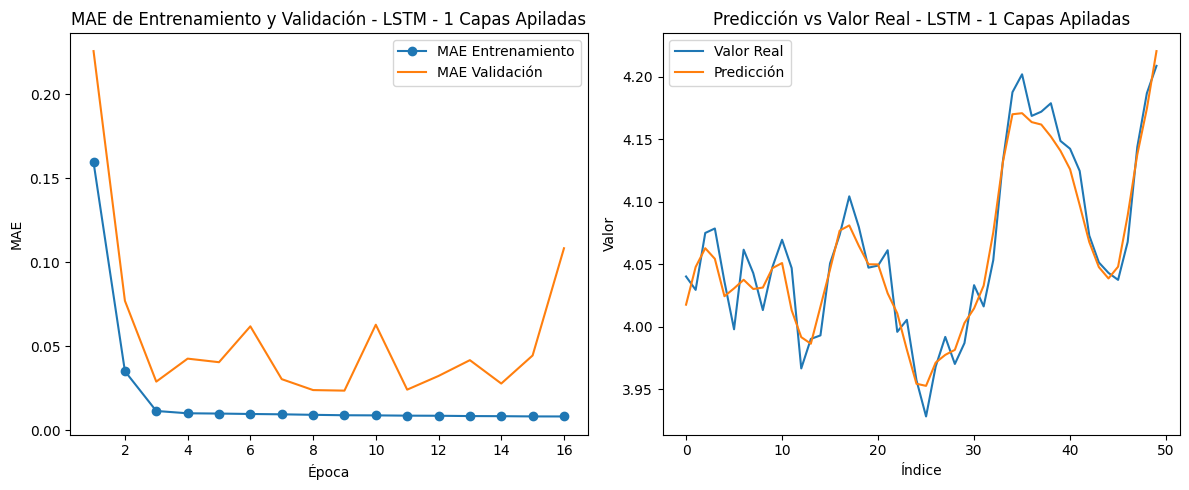

In [26]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas)(inputs)
outputs = layers.Dense(1)(x)
modelo1 = keras.Model(inputs, outputs)

entrenarApilado(modelo1, 1)

Dos capas Apiladas

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MAE de prueba - 2 Capas Apiladas): 1.1325


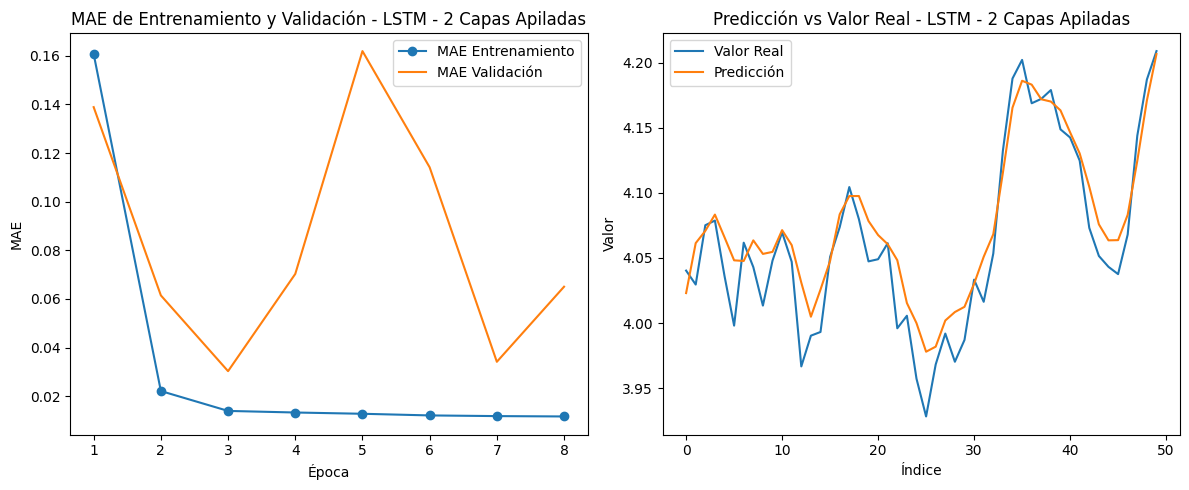

In [13]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas, return_sequences=True)(inputs)
x = layers.LSTM(cantNeuronas)(x)
outputs = layers.Dense(1)(x)
modelo2 = keras.Model(inputs, outputs)

entrenarApilado(modelo2, 2)

3 Capas Apliladas

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba - 3 Capas Apiladas): 1.0909


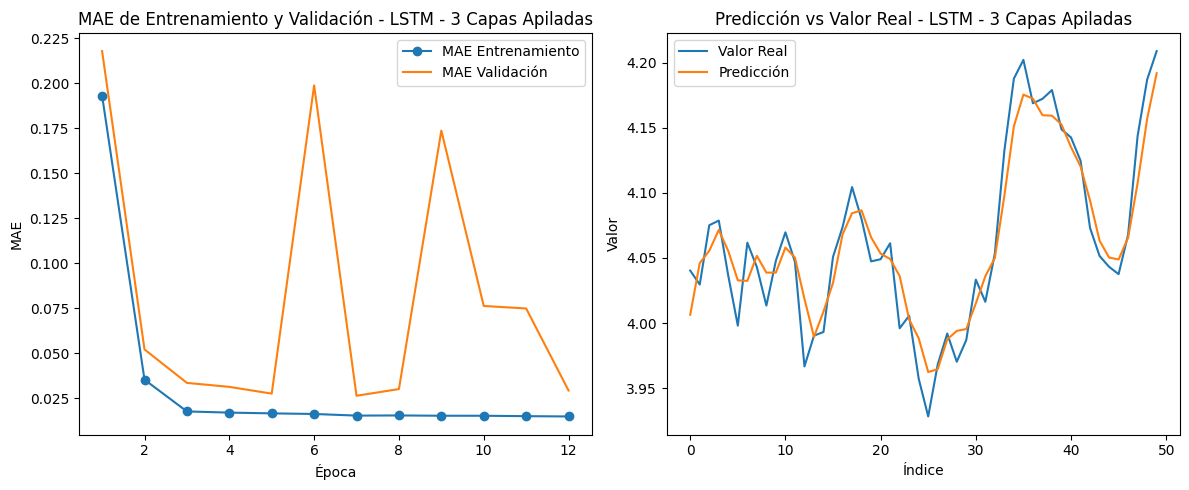

In [15]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(cantNeuronas, return_sequences=True)(inputs)
x = layers.LSTM(cantNeuronas, return_sequences=True)(x)
x = layers.LSTM(cantNeuronas)(x)
outputs = layers.Dense(1)(x)
modelo3 = keras.Model(inputs, outputs)

entrenarApilado(modelo3, 3)

3 Capas de diferente tamaño

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba - 3 Capas Apiladas): 1.5363


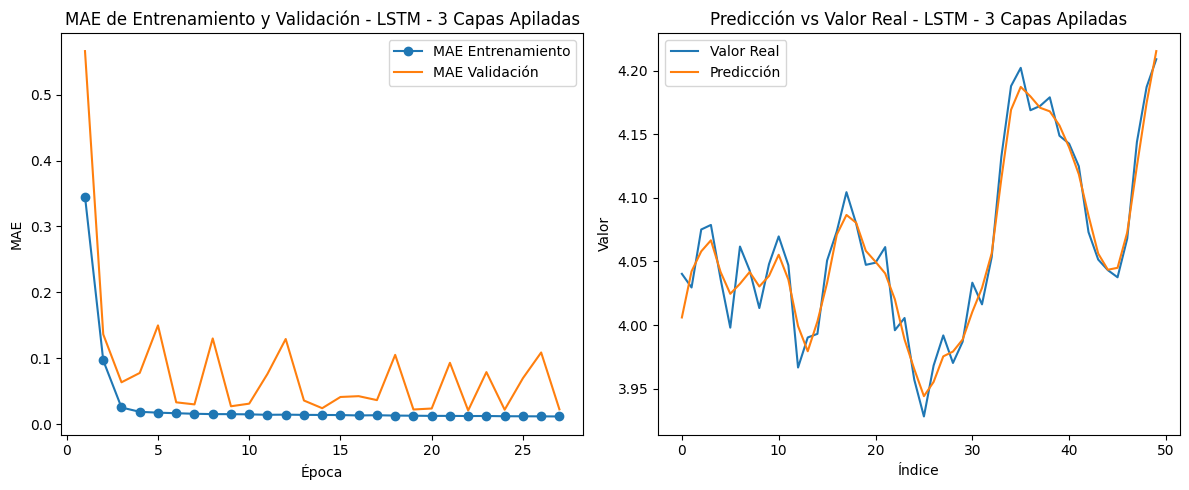

In [20]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(16, return_sequences=True)(inputs)
x = layers.LSTM(8, return_sequences=True)(x)
x = layers.LSTM(4)(x)
outputs = layers.Dense(1)(x)
modelo4 = keras.Model(inputs, outputs)

entrenarApilado(modelo4, 3)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba - 2 Capas Apiladas): 1.4368


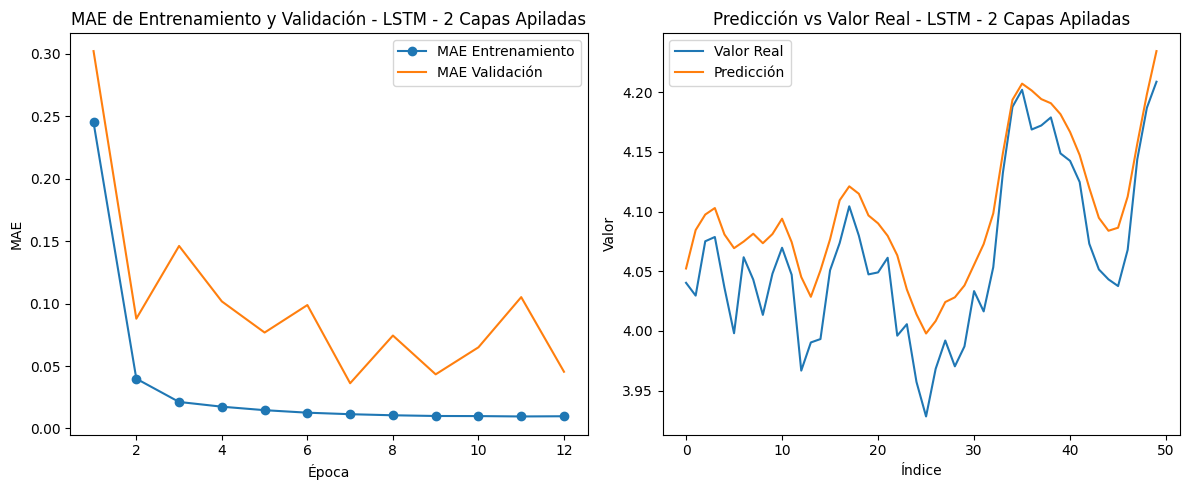

In [21]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(15, return_sequences=True)(inputs)
x = layers.LSTM(5)(x)
outputs = layers.Dense(1)(x)
modelo5 = keras.Model(inputs, outputs)

entrenarApilado(modelo5, 2)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba - 2 Capas Apiladas): 1.0418


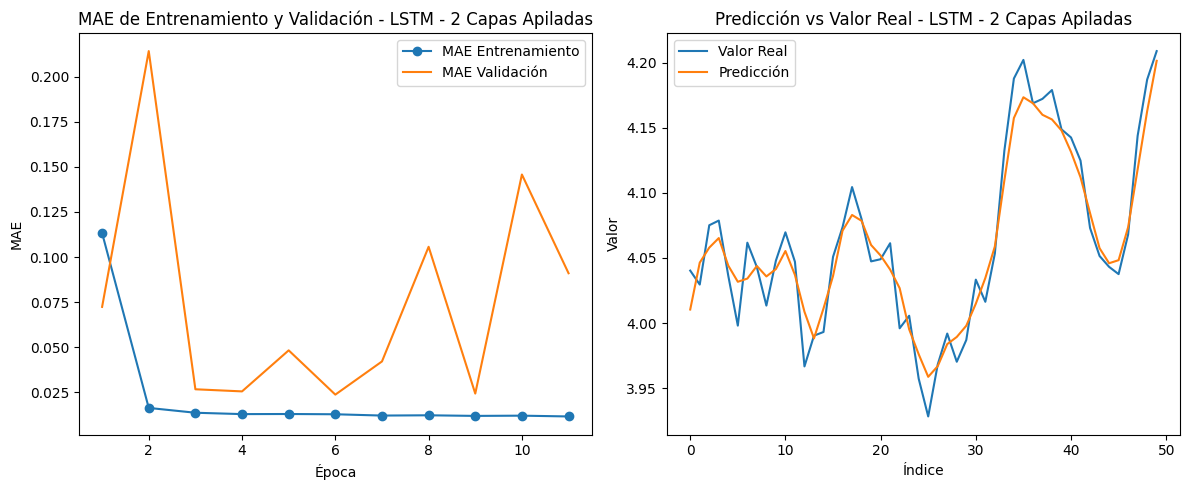

In [25]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(50, return_sequences=True)(inputs)
x = layers.LSTM(15)(x)
outputs = layers.Dense(1)(x)
modelo6 = keras.Model(inputs, outputs)

entrenarApilado(modelo6, 2)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE de prueba - 3 Capas Apiladas): 1.1907


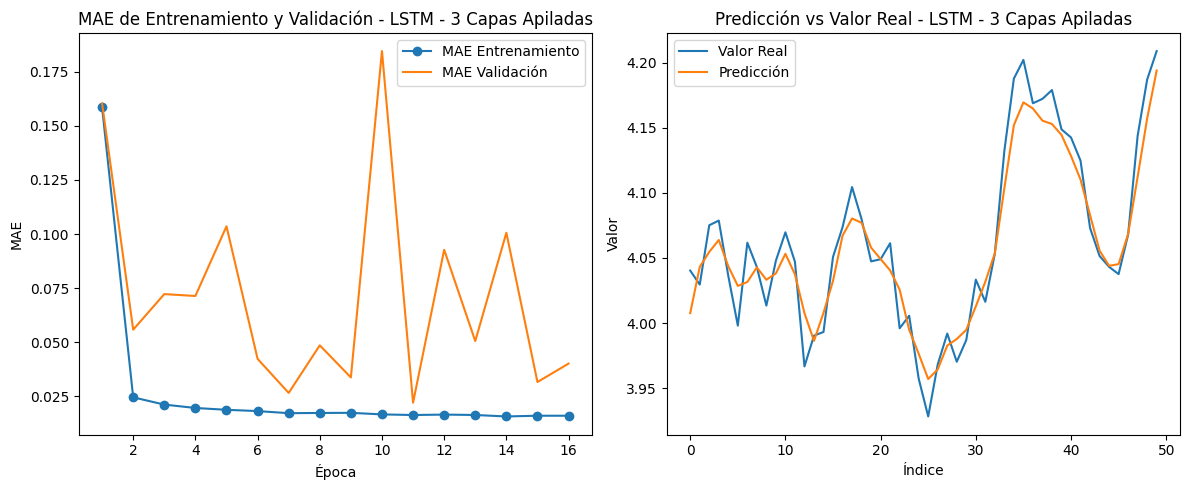

In [23]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.LSTM(16)(x)
outputs = layers.Dense(1)(x)
modelo7 = keras.Model(inputs, outputs)

entrenarApilado(modelo7, 3)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE de prueba - 2 Capas Apiladas): 1.0198


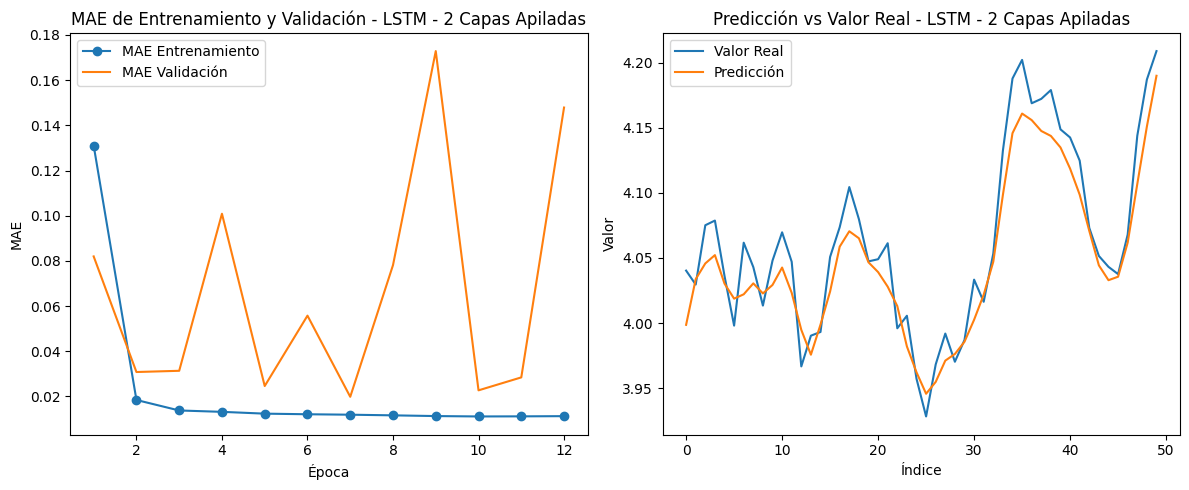

In [24]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(32, return_sequences=True)(inputs)
x = layers.LSTM(16)(x)
outputs = layers.Dense(1)(x)
modelo8 = keras.Model(inputs, outputs)

entrenarApilado(modelo8, 2)